In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('tokyo_weather.csv')

df.head(1)

,Date,Average Temperature (°C),Highest Temperature (°C),Highest Temperature (°C) Datetime,Lowest Temperature (°C),Lowest Temperature (°C) Datetime,Total Precipitation (mm),Sunshine Duration (hours),Maximum Snow Depth (cm),Maximum Snow Depth (cm) Datetime,...,Maximum Wind Speed (m/s) Datetime,Maximum Wind Speed (m/s) Direction,Maximum Gust Speed (m/s),Maximum Gust Speed (m/s) Datetime,Maximum Gust Speed (m/s) Direction,Most Frequent Wind Direction (16-point compass),Average Vapor Pressure (hPa),Average Humidity (%),Minimum Relative Humidity (%),Minimum Relative Humidity (%) Datetime
0,2018/6/26,25.7,30.1,2018/6/26 12:38,22.3,2018/6/26 5:37,0.0,9.2,0,NaN,...,2018/6/26 20:04,S,12.4,2018/6/26 21:03,SSW,SE,24.7,75,56,2018/6/26 12:29


<Axes: xlabel='Date'>

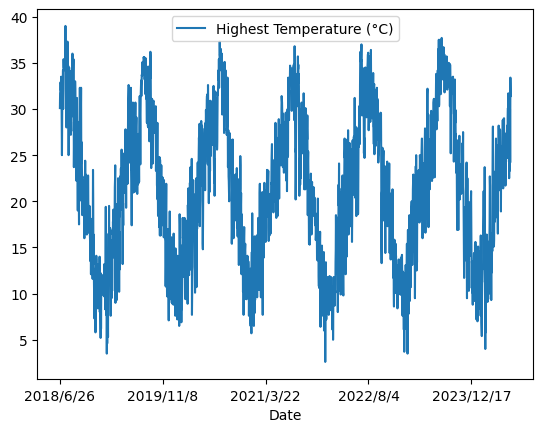

In [7]:
import matplotlib.pyplot as plt
df.plot(x = 'Date' , y = 'Highest Temperature (°C)', kind="line")


#df.plot(x = 'Date' , y = 'Average Temperature (°C)', kind="line")


#df.plot(x = 'Date' , y = 'Lowest Temperature (°C)', kind="line")






In [8]:
#splitting data

df_train = df.iloc[:-30].copy()
df_test = df.iloc[-30:].copy()









p-value: 0.10789068893351478


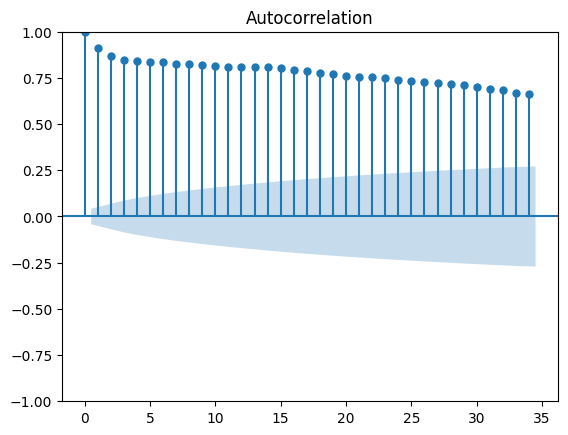

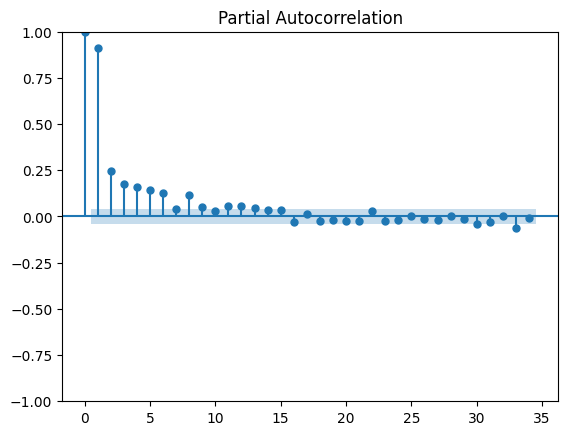

In [12]:
#arima assumptions (differences need to be stationary)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

acf_original = plot_acf(df_train['Highest Temperature (°C)'])

pacf_orginal = plot_pacf(df_train['Highest Temperature (°C)'])
adf_test = adfuller(df_train['Highest Temperature (°C)'])
print(f"p-value: {adf_test[1]}")
#plots show cooked and need to transfrom data to stationary using differencing

#make d = 1

p-value: 2.2677408979384672e-30
                                  SARIMAX Results                                   
Dep. Variable:     Highest Temperature (°C)   No. Observations:                 2163
Model:                       ARIMA(0, 1, 1)   Log Likelihood               -5563.976
Date:                      Wed, 29 Apr 2026   AIC                          11131.951
Time:                              10:24:03   BIC                          11143.309
Sample:                                   0   HQIC                         11136.105
                                     - 2163                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5608      0.016    -35.525      0.000      -0.592      -0.530
sigma2        10.0645      0.283     35.622      0.

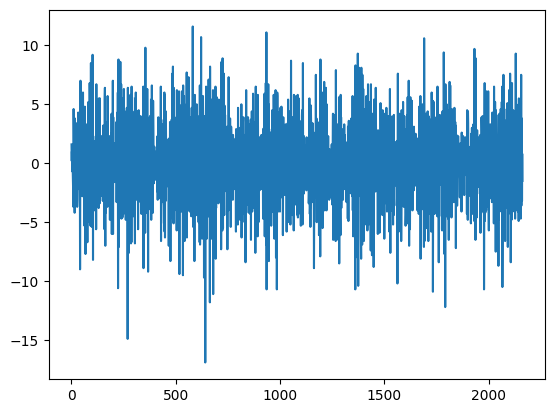

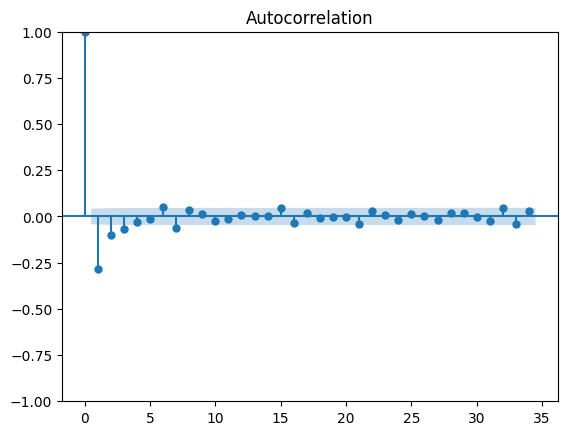

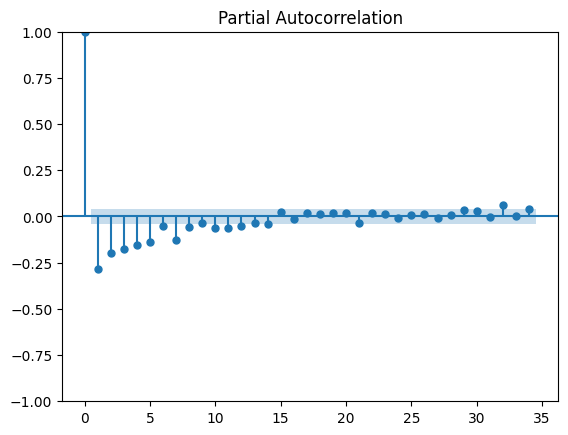

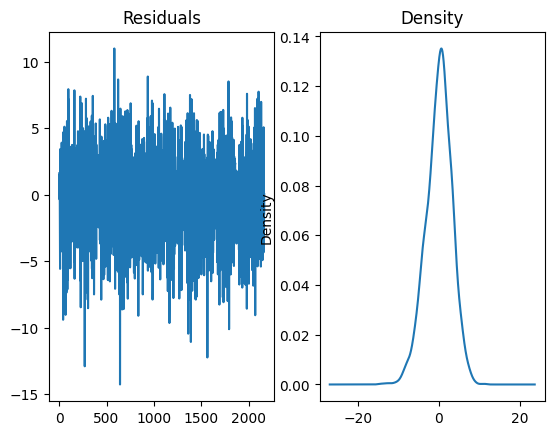

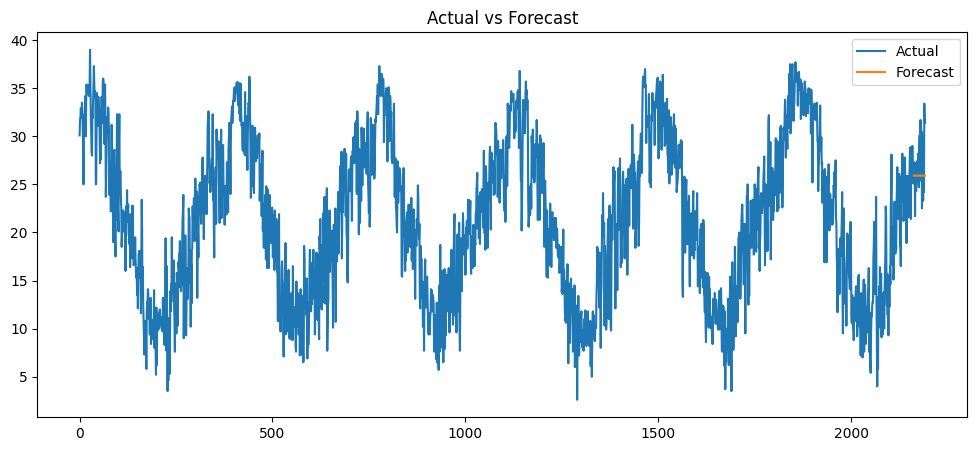

In [13]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
#data now good 

df_train_diff = df_train['Highest Temperature (°C)'].diff().dropna()
df_train_diff.plot()
adf_test = adfuller(df_train_diff)
print(f"p-value: {adf_test[1]}")


acf_original = plot_acf(df_train_diff)

pacf_orginal = plot_pacf(df_train_diff)


#so we say ARIMA(0,1,1)

model = ARIMA(df_train['Highest Temperature (°C)'], order=(0,1,1))
model_fit = model.fit()

print(model_fit.summary())

residuals = model_fit.resid[1:]

fig, ax = plt.subplots(1, 2)

residuals.plot(title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])

plt.show()

forecast_test = model_fit.forecast(steps=len(df_test))

df['forecast_manual'] = [None] * len(df_train) + list(forecast_test)

# Plot only actual temperature and forecast
plt.figure(figsize=(12, 5))
df['Highest Temperature (°C)'].plot(label='Actual')
df['forecast_manual'].plot(label='Forecast')

plt.title("Actual vs Forecast")
plt.legend()
plt.show()

,Date,Actual,Predicted,Error,Absolute Error
2163,2024/5/28,25.9,25.443096,0.456904,0.456904
2164,2024/5/29,25.8,25.533469,0.266531,0.266531
2165,2024/5/30,27.3,25.620538,1.679462,1.679462
2166,2024/5/31,21.7,25.622950,-3.922950,3.922950
2167,2024/6/1,26.3,25.606340,0.693660,0.693660
2168,2024/6/2,24.6,25.583854,-0.983854,0.983854
2169,2024/6/3,24.3,25.563432,-1.263432,1.263432
2170,2024/6/4,25.5,25.544779,-0.044779,0.044779
2171,2024/6/5,27.4,25.527094,1.872906,1.872906
2172,2024/6/6,27.0,25.509715,1.490285,1.490285


MAE: 2.8057115076611354
RMSE: 3.570952154885527


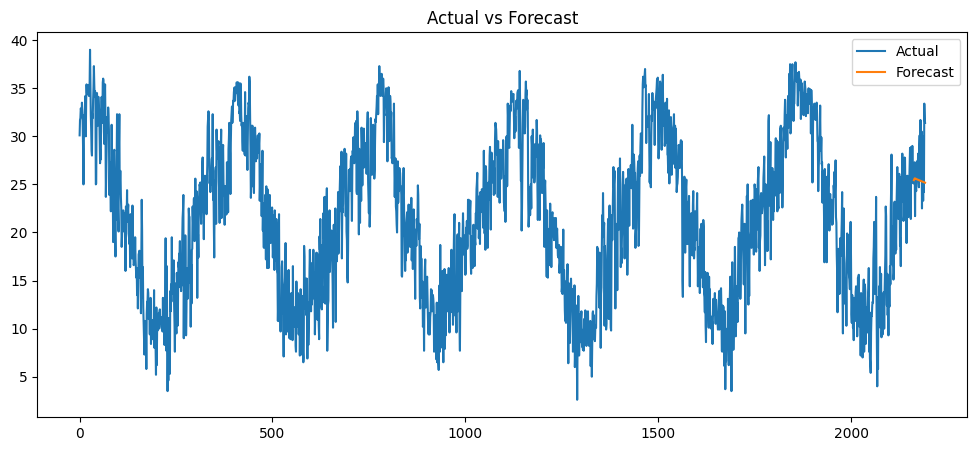

In [ ]:
#something not right when were hand picking so gonna just use a library 
import pmdarima as pm

auto_arima = pm.auto_arima(
    df_train['Highest Temperature (°C)'],
    stepwise=False,
    seasonal=True
)

auto_arima.summary()

forecast_test = auto_arima.predict(n_periods=len(df_test))

comparison_table = pd.DataFrame({
    "Date": df_test["Date"].values if "Date" in df_test.columns else df_test.index,
    "Actual": df_test["Highest Temperature (°C)"].values,
    "Predicted": forecast_test
})

comparison_table["Error"] = comparison_table["Actual"] - comparison_table["Predicted"]
comparison_table["Absolute Error"] = comparison_table["Error"].abs()

display(comparison_table)

# -----------------------------
# Accuracy
# -----------------------------
mae = mean_absolute_error(comparison_table["Actual"], comparison_table["Predicted"])
rmse = np.sqrt(mean_squared_error(comparison_table["Actual"], comparison_table["Predicted"]))

print("MAE:", mae)
print("RMSE:", rmse)




In [ ]:
from sklearn.model_selection import TimeSeriesSplit


#cross valiadation to get lots of model from which get the best and train on all datq




# Define number of splits
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)



NameError: name 'TimeSeriesSplit' is not defined